# 第二十七讲 估计误差与偏差方差

目标：固定同一个总体参数，比较完整估计规则在重复数据集上的误差。先精确枚举，再模拟，最后解释失效。数据全部合成，结果不代表现实任务表现。先修为第19、21–23、25讲。请从第一格顺序运行；本Notebook不读取旧报告。

## 1. 环境与完整性
依赖与Anaconda说明见README。这里只打印文件是否存在，避免依赖绝对目录。图中使用英文标签以兼容没有中文字库的学习环境；解释保留中文。

In [1]:
from pathlib import Path
from fractions import Fraction
import json, math, sys, io
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
import experiment as e
def show(fig):
    fig.tight_layout(pad=1.4)
    buffer = io.BytesIO()
    fig.savefig(buffer, format='png', dpi=140, bbox_inches='tight')
    plt.close(fig)
    display(Image(data=buffer.getvalue()))
expected = {'kind':'synthetic_estimator_risk_demo','seed':27027,'repetitions':10000,
            'sample_sizes':[3,15,63],'center':.5,'gaussian_sigma':1.,
            'contamination_probability':.1,'contamination_sigma':10.,
            'shrinkage_factor':.5,'vanishing_shrinkage_strength':3.,
            'risk_centers':[-2.,-.5,0.,.5,2.]}
e.require(e.load_spec() == expected and e.load_model() == Fraction(1,2),
          'This tutorial uses baseline data; use script --spec for changed designs')
print({'python': sys.version.split()[0], 'numpy': np.__version__,
       'input_present': (e.ROOT/'data/model_spec.json').is_file()})
print(e.self_test())
plt.rcParams.update({'figure.figsize': (8, 3.5), 'axes.spines.top': False,
                     'axes.spines.right': False})


{'python': '3.12.14', 'numpy': '2.3.5', 'input_present': True}
{'core_checks': 8, 'status': 'passed'}


## 2. 全部八种样本，不靠随机数
μ=1/2；±1噪声等概率；n=3。每行权重1/8。先在纸上算完一行，再检查输出。Fraction表示精确算术，这个接口刻意与普通float数值API分开。

In [2]:
mu = e.load_model()
exact = e.exact_two_point(mu, n=3, c=Fraction(1, 2))
for row in exact['rows']:
    print(row)
print(json.dumps(exact['statistics'], ensure_ascii=False, indent=2))


{'signs': [-1, -1, -1], 'estimates': {'mean': '-1/2', 'median': '-1/2', 'fixed_shrinkage': '-1/4'}}
{'signs': [-1, -1, 1], 'estimates': {'mean': '1/6', 'median': '-1/2', 'fixed_shrinkage': '1/12'}}
{'signs': [-1, 1, -1], 'estimates': {'mean': '1/6', 'median': '-1/2', 'fixed_shrinkage': '1/12'}}
{'signs': [-1, 1, 1], 'estimates': {'mean': '5/6', 'median': '3/2', 'fixed_shrinkage': '5/12'}}
{'signs': [1, -1, -1], 'estimates': {'mean': '1/6', 'median': '-1/2', 'fixed_shrinkage': '1/12'}}
{'signs': [1, -1, 1], 'estimates': {'mean': '5/6', 'median': '3/2', 'fixed_shrinkage': '5/12'}}
{'signs': [1, 1, -1], 'estimates': {'mean': '5/6', 'median': '3/2', 'fixed_shrinkage': '5/12'}}
{'signs': [1, 1, 1], 'estimates': {'mean': '3/2', 'median': '3/2', 'fixed_shrinkage': '3/4'}}
{
  "mean": {
    "expectation": "1/2",
    "bias": "0",
    "variance": "1/3",
    "mse": "1/3",
    "new_y_prediction_mse": "4/3"
  },
  "median": {
    "expectation": "1/2",
    "bias": "0",
    "variance": "1",
    "mse"

## 3. 偏差平方与方差相加
主例的中位数无偏但波动大。该两点总体中位数不唯一，不能把本例推广成中位数一般不一致。

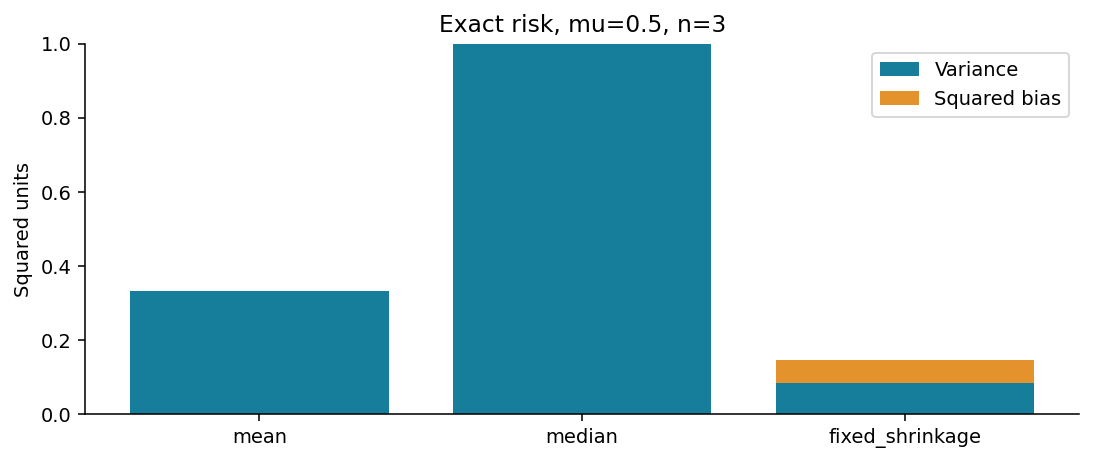

In [3]:
rules = ['mean', 'median', 'fixed_shrinkage']
stats = exact['statistics']
var = [float(Fraction(stats[k]['variance'])) for k in rules]
b2 = [float(Fraction(stats[k]['bias'])**2) for k in rules]
fig, ax = plt.subplots()
ax.bar(rules, var, label='Variance', color='#167d9a')
ax.bar(rules, b2, bottom=var, label='Squared bias', color='#e4932c')
ax.set(ylabel='Squared units', title='Exact risk, mu=0.5, n=3')
ax.legend(); show(fig)


## 4. 换真值会逆转排序
固定c=.5只在|μ|<1时优于均值。oracle使用未知μ，不能当作可部署算法。全部曲线都是理论量，没有事后选择最有利真值。

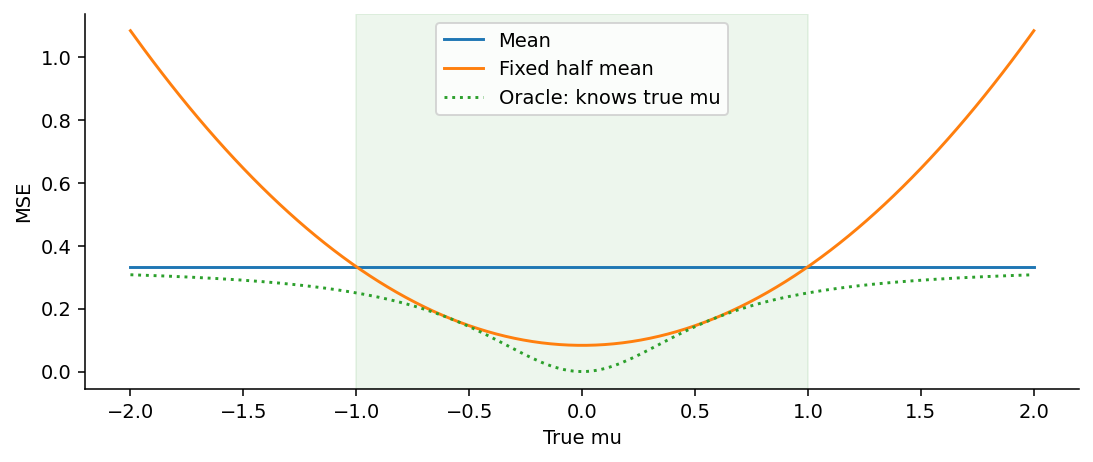

mu=2: {'bias': -1.0, 'variance': 0.08333333333333333, 'mse': 1.0833333333333333}


In [4]:
centers = np.linspace(-2, 2, 201)
mean_risk = [e.shrinkage_risk(float(v), 1, 3, 1)['mse'] for v in centers]
fixed_risk = [e.shrinkage_risk(float(v), 1, 3, .5)['mse'] for v in centers]
oracle = [e.oracle_risk(float(v), 1, 3)['mse_oracle'] for v in centers]
fig, ax = plt.subplots()
ax.plot(centers, mean_risk, label='Mean')
ax.plot(centers, fixed_risk, label='Fixed half mean')
ax.plot(centers, oracle, ':', label='Oracle: knows true mu')
ax.axvspan(-1, 1, color='green', alpha=.07)
ax.set(xlabel='True mu', ylabel='MSE'); ax.legend(); show(fig)
print('mu=2:', e.shrinkage_risk(2, 1, 3, .5))


## 5. 数据选择系数也是估计规则的一部分
c(x)=1{|平均|>1}不是固定c。对每个样本重新选择，直接计算完整风险；禁止用平均系数代入固定系数公式。

In [5]:
chosen = []
for row in exact['rows']:
    avg = Fraction(row['estimates']['mean'])
    chosen.append(avg if abs(avg) > 1 else Fraction(0))
chosen_risk = sum((t-mu)**2 for t in chosen) / len(chosen)
print({'selected_outputs': [str(t) for t in chosen], 'exact_risk': str(chosen_risk)})
e.require(chosen_risk == Fraction(11, 32), 'whole-rule selection risk')


{'selected_outputs': ['0', '0', '0', '0', '0', '0', '0', '3/2'], 'exact_risk': '11/32'}


## 6. 有限列表的精确分母检查
t=(0,1,2)、θ=.5，无随机数。样本方差R−1版本需要乘(R−1)/R。MCSE衡量风险平均的计算精度，不是估计量的标准误。

In [6]:
finite = e.risk_summary([0, 1, 2], .5)
print(finite)
e.require(abs(finite['mse'] - 11/12) < 1e-14, 'finite identity')
print('R-1 correction:', finite['sample_variance_R_minus_1'] * 2/3)


{'R': 3, 'mean_estimate': 1.0, 'bias': 0.5, 'bias_squared': 0.25, 'variance_R': 0.6666666666666666, 'sample_variance_R_minus_1': 1.0, 'mse': 0.9166666666666666, 'identity_residual': 0.0, 'risk_mcse': 0.6666666666666667}
R-1 correction: 0.6666666666666666


## 7. 完整模拟，不读预存结果
每种模型、每个n独立生成R=10000批；每行n个观察。四种规则在相同行计算，因此它们的风险差应视作配对比较。污染成分标准差10，方差100。

In [7]:
spec = e.load_spec()
print(spec)
sim = e.simulation(spec)
rows = sim['rows']
for row in rows:
    print(row['model'], row['n'], row['rule'],
          'bias=', round(row['bias'], 6), 'var_R=', round(row['variance_R'], 6),
          'MSE=', round(row['mse'], 6), 'MCSE=', round(row['risk_mcse'], 6))
e.require(len(rows) == 24, 'expected 2 models x 3 sizes x 4 rules')


{'kind': 'synthetic_estimator_risk_demo', 'seed': 27027, 'repetitions': 10000, 'sample_sizes': [3, 15, 63], 'center': 0.5, 'gaussian_sigma': 1.0, 'contamination_probability': 0.1, 'contamination_sigma': 10.0, 'shrinkage_factor': 0.5, 'vanishing_shrinkage_strength': 3.0, 'risk_centers': [-2.0, -0.5, 0.0, 0.5, 2.0]}


gaussian 3 mean bias= -0.005693 var_R= 0.332782 MSE= 0.332814 MCSE= 0.004645
gaussian 3 median bias= -0.006363 var_R= 0.453762 MSE= 0.453803 MCSE= 0.006429
gaussian 3 fixed_shrinkage bias= -0.252846 var_R= 0.083195 MSE= 0.147127 MCSE= 0.001858
gaussian 3 vanishing_shrinkage bias= -0.252846 var_R= 0.083195 MSE= 0.147127 MCSE= 0.001858
gaussian 15 mean bias= -0.004518 var_R= 0.067552 MSE= 0.067573 MCSE= 0.000947
gaussian 15 median bias= -0.003382 var_R= 0.101651 MSE= 0.101663 MCSE= 0.001469
gaussian 15 fixed_shrinkage bias= -0.252259 var_R= 0.016888 MSE= 0.080523 MCSE= 0.000699
gaussian 15 vanishing_shrinkage bias= -0.087098 var_R= 0.046911 MSE= 0.054497 MCSE= 0.000761
gaussian 63 mean bias= 0.001373 var_R= 0.015974 MSE= 0.015976 MCSE= 0.000225
gaussian 63 median bias= 0.001588 var_R= 0.024857 MSE= 0.024859 MCSE= 0.000348
gaussian 63 fixed_shrinkage bias= -0.249314 var_R= 0.003994 MSE= 0.066151 MCSE= 0.000321
gaussian 63 vanishing_shrinkage bias= -0.021417 var_R= 0.014555 MSE= 0.015014 M

## 8. 两种总体的风险对照
误差条是±2个MC标准误，用于显示有限模拟精度，不作为严格95%区间。中位数有限风险来自模拟；均值与固定线性收缩另有理论可核对值。

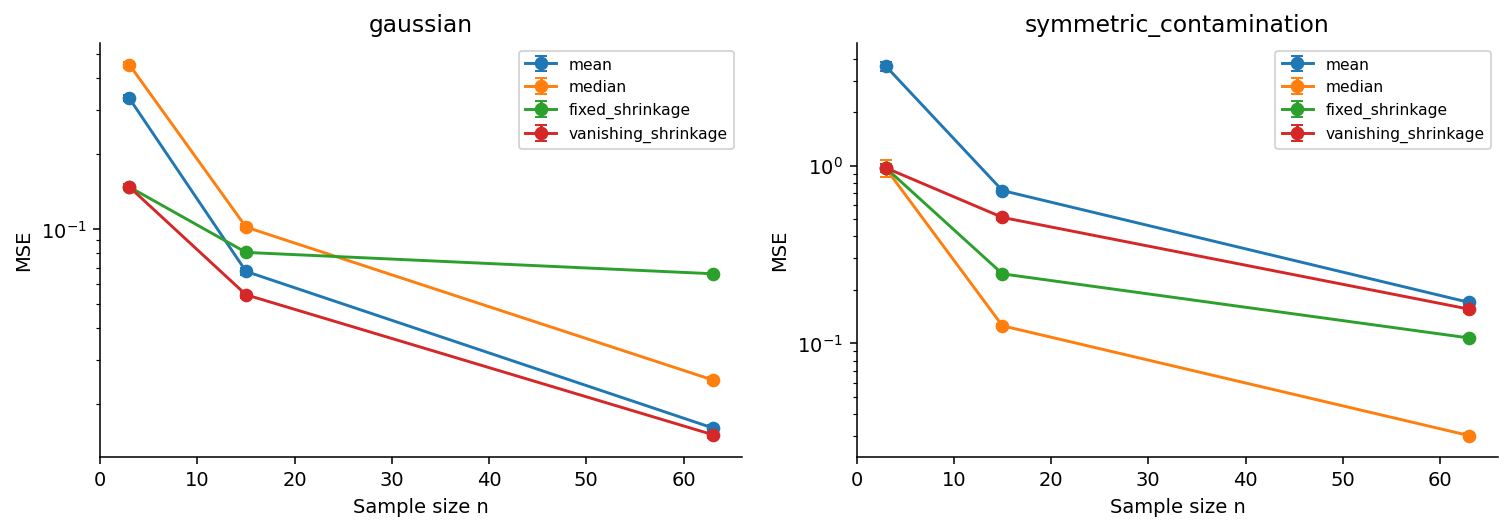

In [8]:
all_rules = ['mean', 'median', 'fixed_shrinkage', 'vanishing_shrinkage']
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, model in zip(axes, ['gaussian', 'symmetric_contamination']):
    for rule in all_rules:
        selected = [r for r in rows if r['model'] == model and r['rule'] == rule]
        ax.errorbar([r['n'] for r in selected], [r['mse'] for r in selected],
                    yerr=[2*r['risk_mcse'] for r in selected], fmt='o-', capsize=3, label=rule)
    ax.set(xlabel='Sample size n', ylabel='MSE', yscale='log', title=model)
    ax.legend(fontsize=8)
fig.tight_layout(); show(fig)


## 9. 同一批数的风险分解
经验偏差即使对应理论无偏规则也不会恰好为0。恒等式的浮点残差与有限模拟偏离真实风险是不同问题。

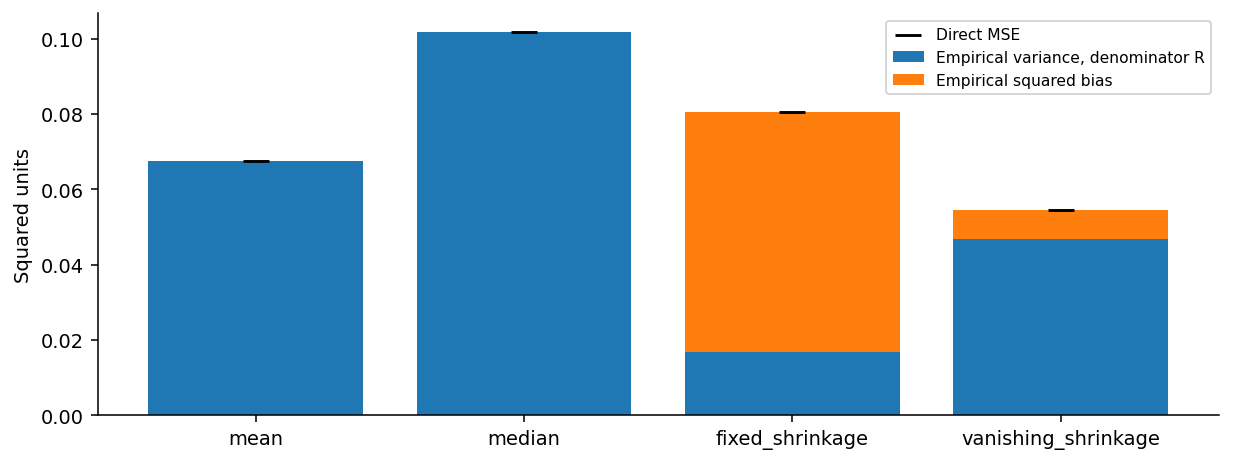

max numerical identity residual: 1.1102230246251565e-16


In [9]:
selected = [r for r in rows if r['model'] == 'gaussian' and r['n'] == 15]
fig, ax = plt.subplots(figsize=(9, 3.5))
names = [r['rule'] for r in selected]
v = [r['variance_R'] for r in selected]; b = [r['bias_squared'] for r in selected]
ax.bar(names, v, label='Empirical variance, denominator R')
ax.bar(names, b, bottom=v, label='Empirical squared bias')
ax.scatter(names, [r['mse'] for r in selected], c='black', marker='_', s=180, label='Direct MSE')
ax.set(ylabel='Squared units'); ax.legend(fontsize=8); show(fig)
print('max numerical identity residual:', max(abs(r['identity_residual']) for r in rows))


## 10. 固定与渐消收缩不能混淆
在μ=.5下，固定半均值的极限MSE为1/16，渐消系数趋1。这里画的是理论风险；不要求一条有限模拟轨迹逐点下降。

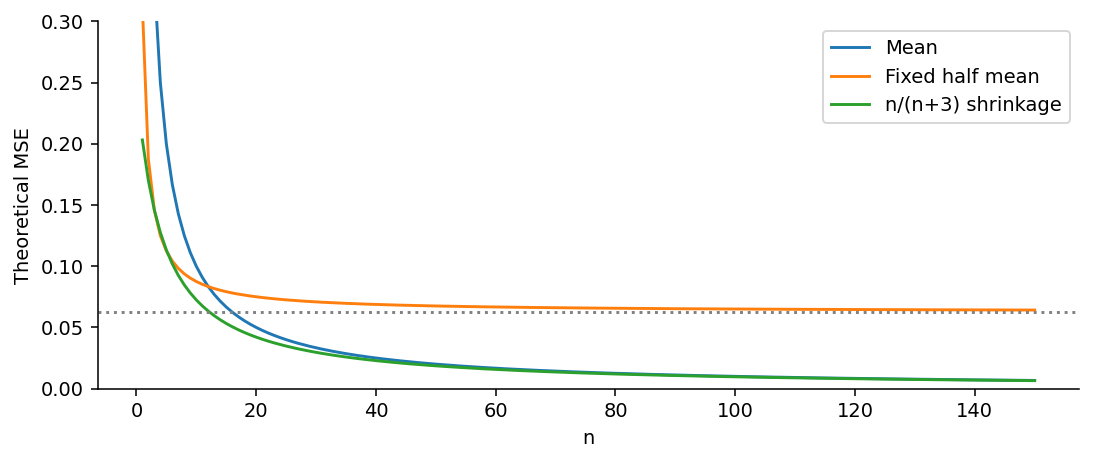

In [10]:
ns = np.arange(1, 151)
fig, ax = plt.subplots()
ax.plot(ns, [e.shrinkage_risk(.5, 1, int(n), 1)['mse'] for n in ns], label='Mean')
ax.plot(ns, [e.shrinkage_risk(.5, 1, int(n), .5)['mse'] for n in ns], label='Fixed half mean')
ax.plot(ns, [e.vanishing_risk(.5, 1, int(n), 3)['mse'] for n in ns], label='n/(n+3) shrinkage')
ax.axhline(1/16, color='gray', linestyle=':')
ax.set(xlabel='n', ylabel='Theoretical MSE', ylim=(0, .3)); ax.legend(); show(fig)


## 11. 精确预测风险与训练复用
对八个训练样本和两个独立新符号全部16种情形求和。若改用训练点，独立性不成立，不能只加噪声方差。

{'mean': '4/3', 'median': '2', 'fixed_shrinkage': '55/48'}


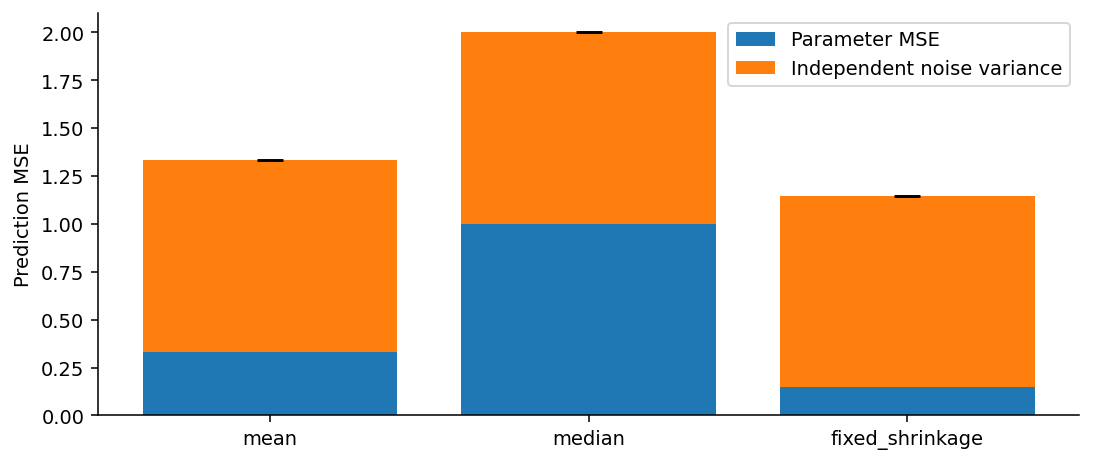

In [11]:
prediction = {}
for rule in rules:
    losses = []
    for row in exact['rows']:
        t = Fraction(row['estimates'][rule])
        losses.extend([(mu+noise-t)**2 for noise in [-1, 1]])
    prediction[rule] = str(sum(losses)/len(losses))
print(prediction)
fig, ax = plt.subplots()
p = [float(Fraction(prediction[k])) for k in rules]
parameter = [float(Fraction(stats[k]['mse'])) for k in rules]
ax.bar(rules, parameter, label='Parameter MSE')
ax.bar(rules, [1]*3, bottom=parameter, label='Independent noise variance')
ax.scatter(rules, p, c='black', marker='_', s=180)
ax.set(ylabel='Prediction MSE'); ax.legend(); show(fig)


## 12. 输入失败、真零与精度限制
全量验证先于RNG。高精度和有理数不能在float API里悄悄变成另一个值；精确接口明确使用Fraction。检查小均值时保留原始数值补偿求和。

In [12]:
calls = [lambda: e.risk_summary([0, 1, True], 0),
         lambda: e.mean([0, float('nan')]),
         lambda: e.risk_summary([0, 1e-200], 0),
         lambda: e.exact_two_point(.5),
         lambda: e.shrinkage_risk(.5, 1, 3, '0.5')]
rejections = 0
for call in calls:
    try:
        call()
    except ValueError:
        rejections += 1
    else:
        raise RuntimeError('invalid input accepted')
print({'expected_rejections': rejections,
       'constant_risk': e.risk_summary([.1, .1, .1], .1)['mse'],
       'retained_small_mean_positive': e.mean([-1, 1, 1e-100]) > 0})


{'expected_rejections': 5, 'constant_risk': 0.0, 'retained_small_mean_positive': True}


## 13. 结论与下一步

- 精确主例：均值、中位数、半均值MSE分别1/3、1、7/48；有偏可降低小样本风险。
- 固定收缩只在部分真值附近改善风险；oracle和数据选择规则必须区分。
- Gaussian与对称污染的实际模拟排序不同。两点中位数反例依赖总体中位数不唯一。
- 样本量n改变统计问题；外层R改变模拟精度；两者不能互换。
- 经验恒等式需分母R；新点预测分解需独立性。

完成lab.pdf的参数改动、输出保护与解释任务。理论假设和完整18题答案见lecture.pdf与answers.pdf。